# Supervised Machine Learning: Regression & Classification Pipelines

This notebook demonstrates end-to-end pipelines for both **Regression** and **Classification** tasks using the `scikit-learn` library. It covers data loading, feature scaling, model training, hyperparameter optimization via cross-validation grid search, and comprehensive model evaluation.

## Part 1: Regression Analysis (Boston Housing Dataset)

We predict housing prices using the Boston Housing Dataset. We implement and compare OLS Linear Regression, Ridge Regression (L2 Regularization), and Lasso Regression (L1 Regularization).

In [1]:
# Import baseline libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Load the Boston Housing Dataset from CMU Statlib
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

boston = {
    'data': data,
    'target': target,
    'feature_names': [
        'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
    ],
    'DESCR': 'Boston Housing Dataset (Original Source)'
}

print(boston['DESCR'])
print(f"Data shape: {boston['data'].shape}")
print(f"Target shape: {boston['target'].shape}")

# Create DataFrame
dataset = pd.DataFrame(boston['data'], columns=boston['feature_names'])
dataset['Price'] = boston['target']
dataset.head()

Boston Housing Dataset (Original Source)
Data shape: (506, 13)
Target shape: (506,)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### Feature Standardization (Scaling)

Standardizing independent features is a crucial step before regularized linear models (Ridge/Lasso) because regularization penalties depend on the absolute magnitudes of model coefficients. Standardizing ensures all features are on the same scale, allowing regularization to act uniformly.

In [3]:
x = dataset.iloc[:, :-1]   # Independent Features
y = dataset.iloc[:, -1]    # Dependent Feature (Price)

# Apply StandardScaler
scaler_reg = StandardScaler()
x_scaled = pd.DataFrame(scaler_reg.fit_transform(x), columns=x.columns)
x_scaled.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501


### 1. Ordinary Least Squares (OLS) Linear Regression

We evaluate an OLS Linear Regression model using 5-fold cross-validation.

In [4]:
lin_reg = LinearRegression()
mse = cross_val_score(lin_reg, x_scaled, y, scoring='neg_mean_squared_error', cv=5)
mean_mse = np.mean(mse)
print(f"OLS Linear Regression 5-Fold CV Mean MSE: {mean_mse:.4f}")

OLS Linear Regression 5-Fold CV Mean MSE: -37.1318


### 2. Ridge Regression

We perform hyperparameter optimization for Ridge Regression (L2 regularization) using grid search over a range of $\alpha$ (lambda) values.

In [5]:
ridge = Ridge()
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55, 100]}

ridge_regressor = GridSearchCV(ridge, parameters, scoring='neg_mean_squared_error', cv=5)
ridge_regressor.fit(x_scaled, y)

print(f"Best Parameters: {ridge_regressor.best_params_}")
print(f"Best 5-Fold CV Mean MSE: {ridge_regressor.best_score_:.4f}")

Best Parameters: {'alpha': 100}
Best 5-Fold CV Mean MSE: -32.3418


### 3. Lasso Regression

We perform hyperparameter optimization for Lasso Regression (L1 regularization). Lasso performs both regularization and variable selection by shrinking less important coefficients to zero.

In [6]:
lasso = Lasso(max_iter=10000) # Set higher max_iter to guarantee convergence
lasso_regressor = GridSearchCV(lasso, parameters, scoring='neg_mean_squared_error', cv=5)
lasso_regressor.fit(x_scaled, y)

print(f"Best Parameters: {lasso_regressor.best_params_}")
print(f"Best 5-Fold CV Mean MSE: {lasso_regressor.best_score_:.4f}")

C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.507e+02, tolerance: 3.919e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.857e+02, tolerance: 3.307e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

Best Parameters: {'alpha': 0.01}
Best 5-Fold CV Mean MSE: -36.6543


### 4. 10-Fold Cross-Validation Comparison

In [7]:
# OLS Linear Regression with CV=10
mse_10 = cross_val_score(lin_reg, x_scaled, y, scoring='neg_mean_squared_error', cv=10)
mean_mse_10 = np.mean(mse_10)

# Ridge with CV=10
ridge_regressor_10 = GridSearchCV(ridge, parameters, scoring='neg_mean_squared_error', cv=10)
ridge_regressor_10.fit(x_scaled, y)

# Lasso with CV=10
lasso_regressor_10 = GridSearchCV(lasso, parameters, scoring='neg_mean_squared_error', cv=10)
lasso_regressor_10.fit(x_scaled, y)

print(f"Linear Regression Mean MSE (CV=10): {mean_mse_10:.4f}")
print(f"Ridge Regression Best Mean MSE (CV=10): {ridge_regressor_10.best_score_:.4f}")
print(f"Lasso Regression Best Mean MSE (CV=10): {lasso_regressor_10.best_score_:.4f}")

C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.606e+02, tolerance: 4.070e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.340e+03, tolerance: 4.117e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.745e+02, tolerance: 3.382e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.045e+03, tolerance: 3.736e+00
  model = cd_fast.enet_coordinate_descent(


Linear Regression Mean MSE (CV=10): -34.7053
Ridge Regression Best Mean MSE (CV=10): -31.1554
Lasso Regression Best Mean MSE (CV=10): -34.5480


### 5. Independent Model Evaluation (77/23 Train-Test Split)

We evaluate performance on a hold-out test set using OLS, Ridge (with optimal $\alpha$), and Lasso (with optimal $\alpha$).

In [8]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.23, random_state=42)

# 1. Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_pred = lin_reg.predict(X_test)
lin_mse = mean_squared_error(y_test, lin_pred)

# 2. Ridge Regression
best_ridge_alpha = ridge_regressor.best_params_['alpha']
ridge_model = Ridge(alpha=best_ridge_alpha)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)

# 3. Lasso Regression
best_lasso_alpha = lasso_regressor.best_params_['alpha']
lasso_model = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)

# Adjusted R-squared calculation
def get_adj_r2(r2, n, k):
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

n = len(y_test)
k = X_test.shape[1]

lin_r2 = r2_score(y_test, lin_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

comparison_metrics = pd.DataFrame({
    'Model': ['Linear (OLS)', 'Ridge', 'Lasso'],
    'MSE': [lin_mse, ridge_mse, lasso_mse],
    'R-squared': [lin_r2, ridge_r2, lasso_r2],
    'Adjusted R-squared': [
        get_adj_r2(lin_r2, n, k),
        get_adj_r2(ridge_r2, n, k),
        get_adj_r2(lasso_r2, n, k)
    ]
})
comparison_metrics

,Model,MSE,R-squared,Adjusted R-squared
0,Linear (OLS),22.969884,0.688337,0.649001
1,Ridge,24.562897,0.666722,0.624658
2,Lasso,23.037556,0.687419,0.647966


### 6. Regression Visualizations

We visualize the performance of our OLS Linear Regression model on the test data.

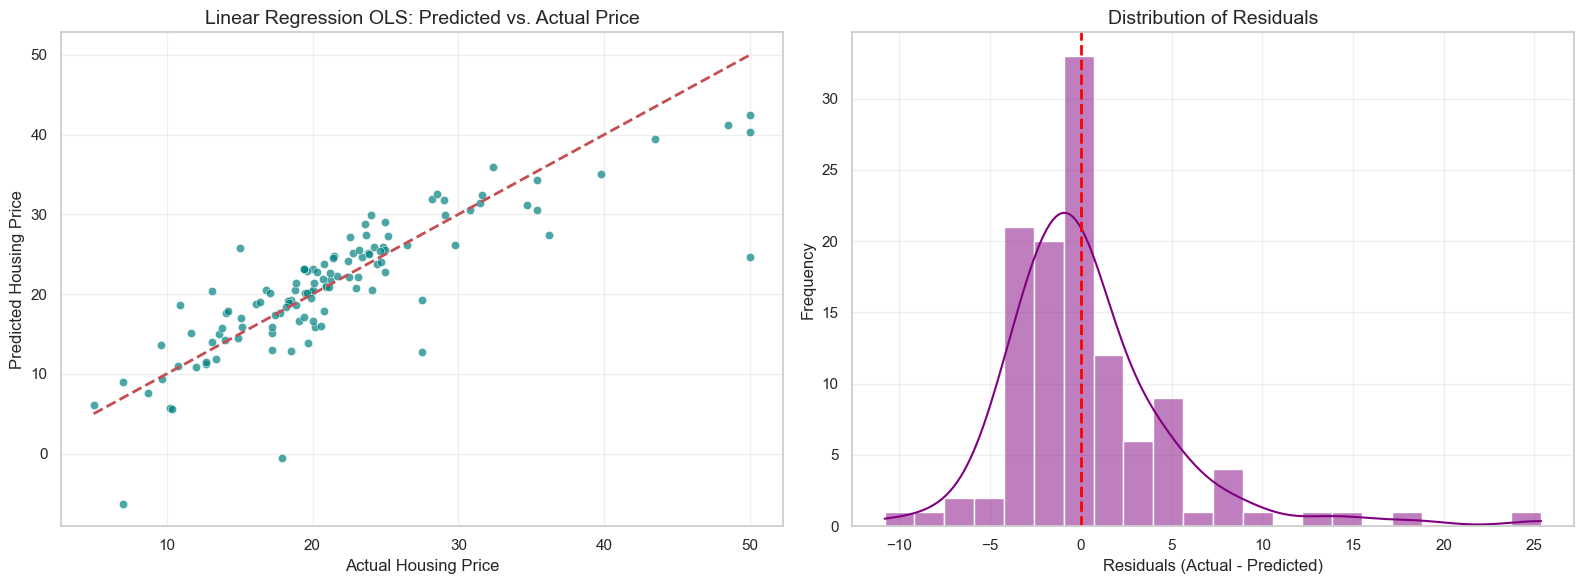

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs. Actual scatter plot
sns.scatterplot(x=y_test, y=lin_pred, ax=axes[0], color='teal', alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title("Linear Regression OLS: Predicted vs. Actual Price", fontsize=14)
axes[0].set_xlabel("Actual Housing Price", fontsize=12)
axes[0].set_ylabel("Predicted Housing Price", fontsize=12)
axes[0].grid(True, alpha=0.3)

# Residual distribution plot
residuals = y_test - lin_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title("Distribution of Residuals", fontsize=14)
axes[1].set_xlabel("Residuals (Actual - Predicted)", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Classification Analysis (Breast Cancer Dataset)

We train a Logistic Regression model to perform binary classification (predicting malignant vs. benign tumors).

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

df = load_breast_cancer()

# Setup Independent and Dependent Features
x_cls = pd.DataFrame(df['data'], columns=df['feature_names'])
y_cls = pd.DataFrame(df['target'], columns=['Target'])

print("Class distribution:")
print(y_cls['Target'].value_counts())
x_cls.head()

Class distribution:
Target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
# Train-Test Split (67% Train, 33% Test)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(x_cls, y_cls, test_size=0.33, random_state=42)

# Standardize Features
scaler_cls = StandardScaler()
X_train_c_scaled = scaler_cls.fit_transform(X_train_c)
X_test_c_scaled = scaler_cls.transform(X_test_c)

print(f"Training set shape: {X_train_c.shape}")
print(f"Testing set shape: {X_test_c.shape}")

Training set shape: (381, 30)
Testing set shape: (188, 30)


In [12]:
# Train Logistic Regression Classifier
classifier = LogisticRegression()
classifier.fit(X_train_c_scaled, y_train_c.values.ravel())

# Predict test results
y_pred_c = classifier.predict(X_test_c_scaled)
y_prob_c = classifier.predict_proba(X_test_c_scaled)[:, 1]

In [13]:
# Evaluate model performance
conf_matrix = confusion_matrix(y_test_c, y_pred_c)
accuracy = accuracy_score(y_test_c, y_pred_c)
report = classification_report(y_test_c, y_pred_c)

print(f"Accuracy Score: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(report)

Accuracy Score: 0.9787

Confusion Matrix:
[[ 66   1]
 [  3 118]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        67
           1       0.99      0.98      0.98       121

    accuracy                           0.98       188
   macro avg       0.97      0.98      0.98       188
weighted avg       0.98      0.98      0.98       188



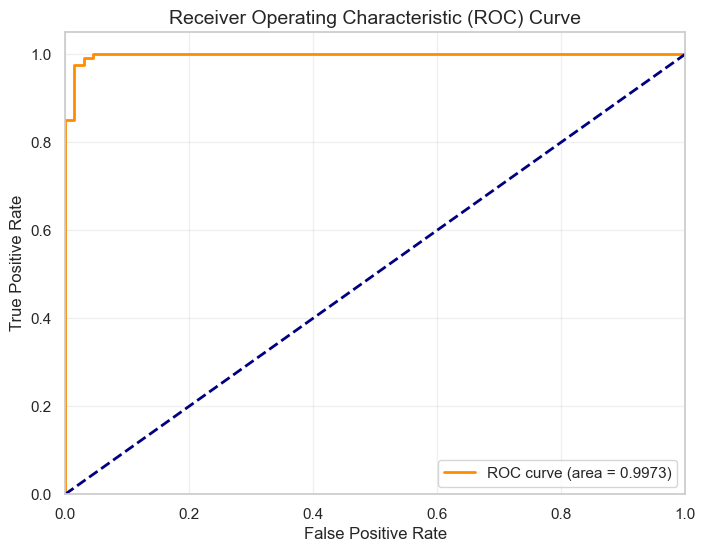

ROC-AUC Score: 0.9973


In [14]:
# Calculate ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_c)
auc_score = roc_auc_score(y_test_c, y_prob_c)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")